# Customer Return Prediction from Marketing Campaigns

## Project Description
**Goal**: Identify customers with high probability of making a repeat purchase within 90 days after interacting with a marketing message.

**Data**: The project uses anonymized data about:
- Marketing messages (channel type, event type, date and time)
- Purchases (date, amount, quantity, product categories)
- Target variable (target = 1 if customer returned with a purchase within 90 days)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datetime import datetime
import shap
import os

from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import roc_auc_score

# Utility libraries
import warnings
warnings.filterwarnings('ignore')

# Create directory for report images
os.makedirs('reports/images', exist_ok=True)

In [2]:
# Constants
RANDOM_STATE = 42

## 2. Data Loading and Initial Analysis

In [3]:
messages = pd.read_csv('../../datasets/apparel-messages.csv')
purchases = pd.read_csv('../../datasets/apparel-purchases.csv')
target = pd.read_csv('../../datasets/apparel-target_binary.csv')

In [4]:
messages.head()

,bulk_campaign_id,client_id,message_id,event,channel,date,created_at
0,4439,1515915625626736623,1515915625626736623-4439-6283415ac07ea,open,email,2022-05-19,2022-05-19 00:14:20
1,4439,1515915625490086521,1515915625490086521-4439-62834150016dd,open,email,2022-05-19,2022-05-19 00:39:34
2,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,open,email,2022-05-19,2022-05-19 00:51:49
3,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,click,email,2022-05-19,2022-05-19 00:52:20
4,4439,1515915625471518311,1515915625471518311-4439-628341570c133,open,email,2022-05-19,2022-05-19 00:56:52


In [5]:
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12739798 entries, 0 to 12739797
Data columns (total 7 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   bulk_campaign_id  int64 
 1   client_id         int64 
 2   message_id        object
 3   event             object
 4   channel           object
 5   date              object
 6   created_at        object
dtypes: int64(2), object(5)
memory usage: 680.4+ MB


In [6]:
purchases.head()

,client_id,quantity,price,category_ids,date,message_id
0,1515915625468169594,1,1999.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
1,1515915625468169594,1,2499.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
2,1515915625471138230,1,6499.0,"['4', '28', '57', '431']",2022-05-16,1515915625471138230-4437-6282242f27843
3,1515915625471138230,1,4999.0,"['4', '28', '244', '432']",2022-05-16,1515915625471138230-4437-6282242f27843
4,1515915625471138230,1,4999.0,"['4', '28', '49', '413']",2022-05-16,1515915625471138230-4437-6282242f27843


In [7]:
purchases.info()
purchases.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202208 entries, 0 to 202207
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   client_id     202208 non-null  int64  
 1   quantity      202208 non-null  int64  
 2   price         202208 non-null  float64
 3   category_ids  202208 non-null  object 
 4   date          202208 non-null  object 
 5   message_id    202208 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 9.3+ MB


,client_id,quantity,price
count,2.022080e+05,202208.000000,202208.000000
mean,1.515916e+18,1.006483,1193.301516
std,1.459514e+08,0.184384,1342.252664
min,1.515916e+18,1.000000,1.000000
25%,1.515916e+18,1.000000,352.000000
50%,1.515916e+18,1.000000,987.000000
75%,1.515916e+18,1.000000,1699.000000
max,1.515916e+18,30.000000,85499.000000


In [8]:
target.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49849 entries, 0 to 49848
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   client_id  49849 non-null  int64
 1   target     49849 non-null  int64
dtypes: int64(2)
memory usage: 779.0 KB


In [9]:
target.head()

,client_id,target
0,1515915625468060902,0
1,1515915625468061003,1
2,1515915625468061099,0
3,1515915625468061100,0
4,1515915625468061170,0


**Conclusions:**
Three datasets loaded: `messages` (12.7M records), `purchases` (202K records), `target` (49K customers).

No missing values detected. Some date columns are loaded as strings and require explicit conversion.

The data contains information about marketing interactions, purchases, and target variable, ready for further processing.

## 3. Data Preprocessing

### 3.1 Data Transformation

In [10]:
# Convert dates
purchases['date'] = pd.to_datetime(purchases['date'], errors='coerce')
messages['date'] = pd.to_datetime(messages['date'], errors='coerce')
messages['created_at'] = pd.to_datetime(messages['created_at'], errors='coerce')

All date columns (`date`, `created_at`) have been converted to `datetime` type for working with time-based features.

In [11]:
# Convert category_ids from string to list
def parse_category_ids(val):
    if pd.isna(val) or val.strip() in ("[]", "['None']", "[None]", ""):
        return []
    try:
        return [int(x.strip().strip("'").strip('"')) for x in val.strip("[]").split(',')]
    except Exception as e:
        print(f"Error parsing: {val} — {e}")
        return []

purchases['category_ids'] = purchases['category_ids'].apply(parse_category_ids)

Values in the `category_ids` column, represented as string lists, have been converted to actual lists of integers for subsequent processing.

### 3.2 Anomaly Handling

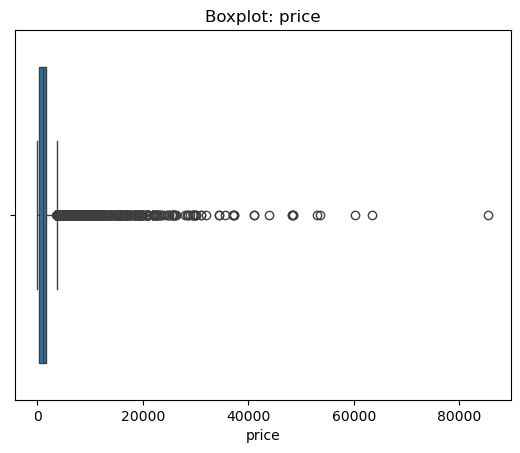

count    202208.000000
mean       1193.301516
std        1342.252664
min           1.000000
25%         352.000000
50%         987.000000
75%        1699.000000
max       85499.000000
Name: price, dtype: float64


In [12]:
# Check price distribution
sns.boxplot(x=purchases['price'])
plt.title('Boxplot: price')
plt.show()

print(purchases['price'].describe())

In [13]:
purchases.sort_values(by='price', ascending=False).head(10)

,client_id,quantity,price,category_ids,date,message_id
186736,1515915625553309277,1,85499.0,"[4, 29, 313, 1574]",2023-12-24,1515915625553309277-14352-6585585d7a711
166576,1515915625776653984,1,63499.0,"[4, 29, 310, 1577]",2023-08-26,1515915625776653984-13719-64e85f9332bc8
166578,1515915625776653984,1,60200.0,"[4, 29, 310, 1577]",2023-08-26,1515915625776653984-13719-64e85f9332bc8
138818,1515915625971673322,1,53499.0,"[4, 29, 310, 1577]",2023-06-13,1515915625971673322-13342-648873c693815
171436,1515915625959777467,1,52999.0,"[4, 29, 313, 1574]",2023-09-27,1515915625959777467-13868-6513cbb257da6
6018,1515915625692218402,1,48499.0,"[4, 29, 312, 1576]",2022-06-01,1515915625489907961-4679-62972222453b3
171435,1515915625959777467,1,48499.0,"[4, 29, 313, 1574]",2023-09-27,1515915625959777467-13868-6513cbb257da6
198463,1515915625995288129,1,48299.0,"[4, 29, 310, 1577]",2024-01-31,1515915625995288129-14553-65b65deea7556
198462,1515915625995288129,1,48299.0,"[4, 29, 310, 1577]",2024-01-31,1515915625995288129-14553-65b65deea7556
171434,1515915625959777467,1,43999.0,"[4, 29, 313, 1574]",2023-09-27,1515915625959777467-13868-6513cbb257da6


Distribution with a large number of outliers. However, the values look realistic (high prices may be related to expensive categories), so they are kept unchanged.

In [14]:
# Check quantity values
purchases['quantity'].value_counts().sort_index()

quantity
1     201323
2        751
3         94
4         12
5          3
6          5
7          1
8          1
9          2
10         4
13         1
15         3
18         1
20         3
25         2
30         2
Name: count, dtype: int64

Most purchases are for 1 unit. Other values occur rarely but appear valid. No removal required.

In [15]:
# Check most frequent category_ids values
flat_categories = purchases['category_ids'].explode()
Counter(flat_categories).most_common(10)

[(4, 112578),
 (28, 80143),
 (5562, 46511),
 (2, 27429),
 (18, 24314),
 (27, 12216),
 (5630, 9753),
 (260, 8853),
 (62, 8675),
 (57, 8626)]

- Frequently occurring categories look reasonable.
- No strange IDs like 999999 or None found.
- `category_ids` is clean and ready for use in analysis or feature generation.

In [16]:
# Check event values
messages['event'].value_counts()

event
send           9058196
open           3085820
click           496339
purchase         64679
hard_bounce      19903
soft_bounce      10583
unsubscribe       2841
hbq_spam           823
complain           528
subscribe           85
close                1
Name: count, dtype: int64

All events are clear, except for 'close' which will be removed.

In [17]:
# Remove 'close' event
messages = messages[messages['event'] != 'close']

In [18]:
# Check channel values
messages['channel'].value_counts()

channel
mobile_push    7512155
email          5227642
Name: count, dtype: int64

Values `email` and `mobile_push` are valid. The balance between them is logical for m-commerce.

In [19]:
messages['created_at'].min(), messages['created_at'].max()

(Timestamp('2022-05-19 00:14:20'), Timestamp('2024-02-15 23:58:40'))

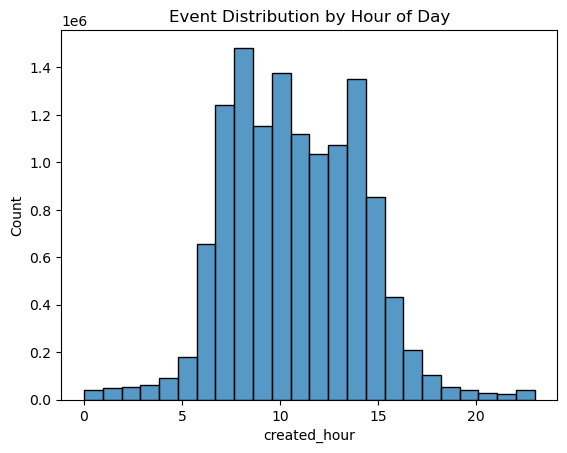

In [20]:
messages['created_hour'] = messages['created_at'].dt.hour
sns.histplot(messages['created_hour'], bins=24)
plt.title('Event Distribution by Hour of Day')
plt.show()

- Date range: May 19, 2022 - February 15, 2024
- Normal distribution with peak at 7-15 hours - active part of the day

### 3.3 Duplicate Handling

In [21]:
# Full duplicates in messages
messages_dups = messages.duplicated()
print(f"Full duplicates: {messages_dups.sum()}")

# Partial duplicates by key events in messages
messages_dups_key = messages.duplicated(subset=['client_id', 'message_id', 'event', 'channel', 'created_at'])
print(f"Duplicates by key fields: {messages_dups_key.sum()}")

Full duplicates: 48610
Duplicates by key fields: 48610


In [22]:
# Copy to preserve original
purchases_check = purchases.copy()

# Convert category_ids to string (with sorting — so [4,28] and [28,4] are considered identical)
purchases_check['category_ids_str'] = purchases_check['category_ids'].apply(
    lambda x: ','.join(map(str, sorted(x))) if isinstance(x, list) else ''
)

# Full duplicates (including category_ids as string)
purchases_check_full = purchases_check.copy()
purchases_check_full = purchases_check_full.drop(columns=['category_ids'])  # remove non-comparable column
purchases_check_full['category_ids'] = purchases_check['category_ids_str']

full_dups = purchases_check_full.duplicated().sum()
print(f"[purchases] Full duplicates: {full_dups}")

# Duplicates by key fields
key_cols = ['client_id', 'date', 'message_id', 'price', 'quantity', 'category_ids_str']
key_dups = purchases_check.duplicated(subset=key_cols).sum()
print(f"[purchases] Duplicates by key fields: {key_dups}")

[purchases] Full duplicates: 73024
[purchases] Duplicates by key fields: 73024


In [23]:
# Remove duplicates from messages
messages = messages.drop_duplicates(subset=['client_id', 'message_id', 'event', 'channel', 'created_at'])
print(f"[messages] After removal: {messages.shape[0]} rows")

[messages] After removal: 12691187 rows


In [24]:
# Remove duplicates from purchases (handling category_ids)
# Create string key from category_ids
purchases['category_ids_str'] = purchases['category_ids'].apply(
    lambda x: ','.join(map(str, sorted(x))) if isinstance(x, list) else ''
)

# Remove duplicates by key fields
purchases = purchases.drop_duplicates(
    subset=['client_id', 'date', 'message_id', 'price', 'quantity', 'category_ids_str']
)

# Remove temporary field
purchases.drop(columns=['category_ids_str'], inplace=True)

print(f"[purchases] After removal: {purchases.shape[0]} rows")

[purchases] After removal: 129184 rows


### 3.4 Conclusions

Data has been successfully cleaned and converted to working format. Completed steps:

- Type conversions.
- List value processing.
- Anomaly and duplicate detection and removal.

All steps form a reliable foundation for further analysis and feature engineering.

## 4. Exploratory Data Analysis (EDA)

### 4.1 Data Merging

Goal: create a unified dataset containing purchase information, marketing events, and target variable.

In [25]:
purchases_merged = purchases.merge(
    messages,
    on=['message_id', 'client_id'],
    how='left',
    suffixes=('_purchase', '_message')
)

In [26]:
purchases_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535930 entries, 0 to 535929
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   client_id         535930 non-null  int64         
 1   quantity          535930 non-null  int64         
 2   price             535930 non-null  float64       
 3   category_ids      535930 non-null  object        
 4   date_purchase     535930 non-null  datetime64[ns]
 5   message_id        535930 non-null  object        
 6   bulk_campaign_id  502105 non-null  float64       
 7   event             502105 non-null  object        
 8   channel           502105 non-null  object        
 9   date_message      502105 non-null  datetime64[ns]
 10  created_at        502105 non-null  datetime64[ns]
 11  created_hour      502105 non-null  float64       
dtypes: datetime64[ns](3), float64(3), int64(2), object(4)
memory usage: 49.1+ MB


We see some purchases for which no corresponding messages were found. Let's merge the resulting table with the target and examine the data in more detail.

In [27]:
purchases_full = purchases_merged.merge(
    target,
    on='client_id',
    how='left'
)

In [28]:
purchases_full.head()

,client_id,quantity,price,category_ids,date_purchase,message_id,bulk_campaign_id,event,channel,date_message,created_at,created_hour,target
0,1515915625468169594,1,1999.0,"[4, 28, 57, 431]",2022-05-16,1515915625468169594-4301-627b661e9736d,NaN,NaN,NaN,NaT,NaT,NaN,0
1,1515915625468169594,1,2499.0,"[4, 28, 57, 431]",2022-05-16,1515915625468169594-4301-627b661e9736d,NaN,NaN,NaN,NaT,NaT,NaN,0
2,1515915625471138230,1,6499.0,"[4, 28, 57, 431]",2022-05-16,1515915625471138230-4437-6282242f27843,NaN,NaN,NaN,NaT,NaT,NaN,0
3,1515915625471138230,1,4999.0,"[4, 28, 244, 432]",2022-05-16,1515915625471138230-4437-6282242f27843,NaN,NaN,NaN,NaT,NaT,NaN,0
4,1515915625471138230,1,4999.0,"[4, 28, 49, 413]",2022-05-16,1515915625471138230-4437-6282242f27843,NaN,NaN,NaN,NaT,NaT,NaN,0


In [29]:
purchases_full.loc[(purchases_full['target'] == 1) & (purchases_full['bulk_campaign_id'].isna())].shape

(940, 13)

There are 940 records where target is positive but no preceding message was found. We need to check if such messages actually don't exist or if we're dealing with a technical error and client_id was mixed up for the corresponding message_id.

In [30]:
messages[messages['message_id'] == '1515915625468063026-4439-628341397ba7a']

,bulk_campaign_id,client_id,message_id,event,channel,date,created_at,created_hour


Such messages simply don't exist, which allows us to conclude that some purchases were made without a marketing message. Let's mark them separately.

In [31]:
purchases_full['has_message'] = purchases_full['event'].notna().astype(int)

purchases_full['event'] = purchases_full['event'].fillna('no_event')
purchases_full['channel'] = purchases_full['channel'].fillna('no_channel')
purchases_full['bulk_campaign_id'] = purchases_full['bulk_campaign_id'].fillna(-1)
purchases_full['created_at'] = purchases_full['created_at'].fillna(pd.NaT)
purchases_full['created_hour'] = purchases_full['created_hour'].fillna(-1)

Tables `purchases` and `messages` were merged by `message_id` and `client_id`, then the target variable was joined by `client_id`.

Added `has_message` feature indicating presence of corresponding message for a purchase. Some records with `target = 1` have no associated message - this is correct since the user could return independently of marketing influence.

**Conclusion:** merge performed correctly. Logic of `has_message` feature formation is justified.

### 4.2 Feature Distributions

#### Numerical Feature Distributions

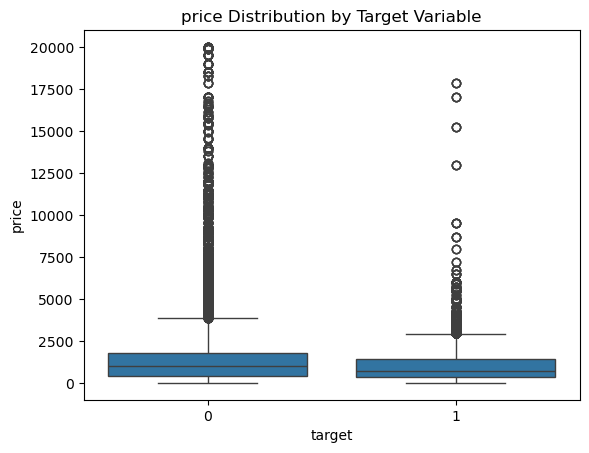

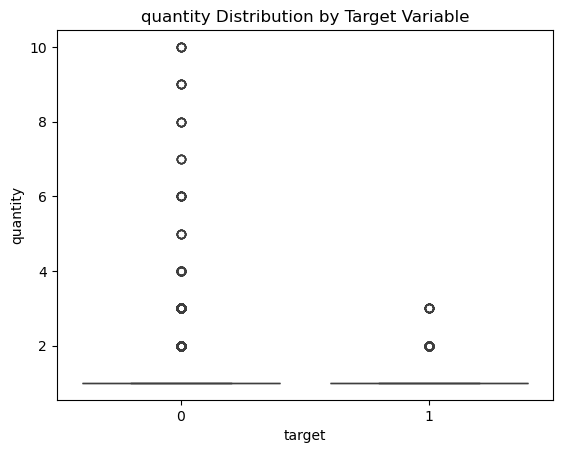

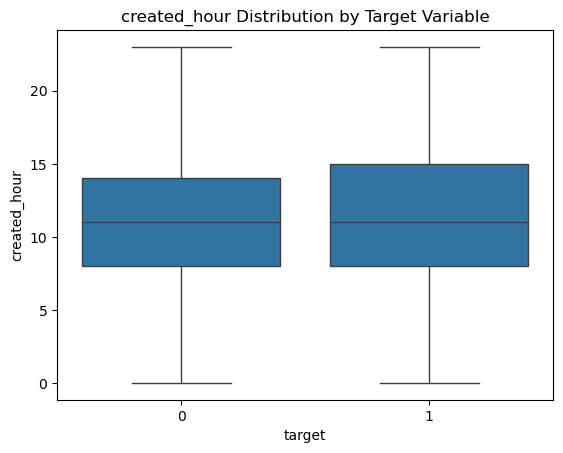

In [32]:
# Numerical features for analysis
num_cols = ['price', 'quantity', 'created_hour']

# Limit price and quantity for analysis
purchases_clean = purchases_full.copy()
purchases_clean = purchases_clean[purchases_clean['price'] <= 20000]
purchases_clean = purchases_clean[purchases_clean['quantity'] <= 10]
purchases_clean = purchases_clean[purchases_clean['created_hour'] >= 0]

for col in num_cols:
    sns.boxplot(data=purchases_clean, x='target', y=col)
    plt.title(f'{col} Distribution by Target Variable')
    plt.show()

`price` - Users with target = 1 (who made a purchase within 90 days) on average buy cheaper products than those with target = 0. This may indicate a tendency for regular inexpensive purchases among the active audience.

`quantity` - Number of purchased items is almost always 1 in both groups. No significant difference observed.

`created_hour` - Median interaction time values are nearly identical in both groups. No significant difference in hourly activity between users with target = 1 and target = 0.

In [33]:
# For each categorical feature value, calculate the proportion of users
# who completed target action (target = 1) and those who didn't (target = 0)
# This helps assess the relationship between each category and target action

for col in ['event', 'channel', 'has_message']:
    crosstab = pd.crosstab(purchases_full[col], purchases_full['target'], normalize='index').round(3)
    display(crosstab)

target,0,1
event,,
click,0.959,0.041
complain,1.000,0.000
hard_bounce,0.935,0.065
no_event,0.972,0.028
open,0.964,0.036
purchase,0.961,0.039
send,0.967,0.033
subscribe,1.000,0.000
unsubscribe,1.000,0.000


target,0,1
channel,,
email,0.964,0.036
mobile_push,0.958,0.042
no_channel,0.972,0.028


target,0,1
has_message,,
0,0.972,0.028
1,0.962,0.038


- `click` and `purchase` in `event` are associated with slightly higher `target = 1` proportion, but difference is still small
- `hard_bounce` unexpectedly shows highest percentage (6.5%) - possibly random due to small sample
- `complain`, `unsubscribe`, `subscribe` - no purchases at all
- `mobile_push` is more effective than `email` for conversion (4.2% vs 3.6%)
- Having a message (`has_message = 1`) gives 3.8% activity - not much, but better than 0

In [34]:
# Target variable distribution for those who didn't receive messages
crosstab = pd.crosstab(
    purchases_full[purchases_full['has_message'] == 0]['has_message'],
    purchases_full[purchases_full['has_message'] == 0]['target'],
    normalize='index'
).round(3)

display(crosstab)

target,0,1
has_message,,
0,0.972,0.028


- Without messages (`has_message = 0`) the share of `target = 1` is **2.8%**
- With messages (`has_message = 1`) - **3.8%**

Conclusion: messages provide **+1% activity increase**, though not radical.

#### Categorical Feature Distributions

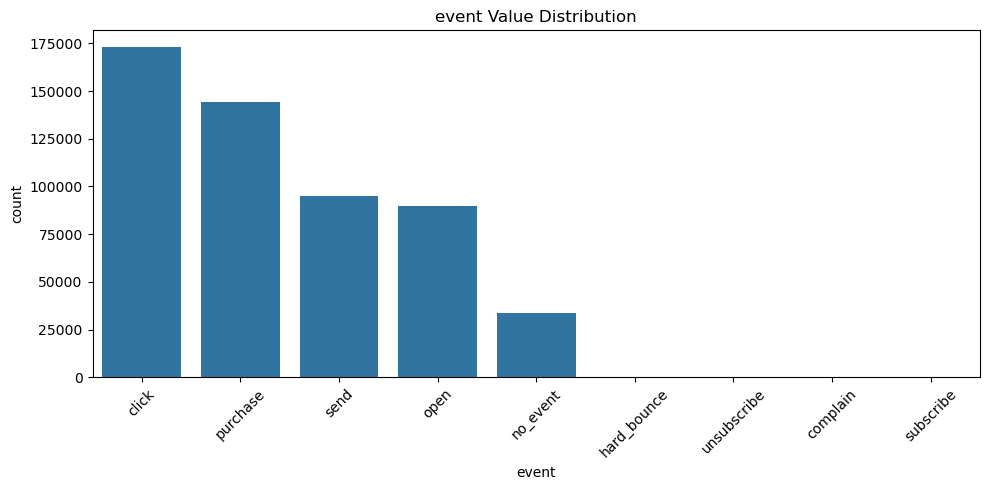

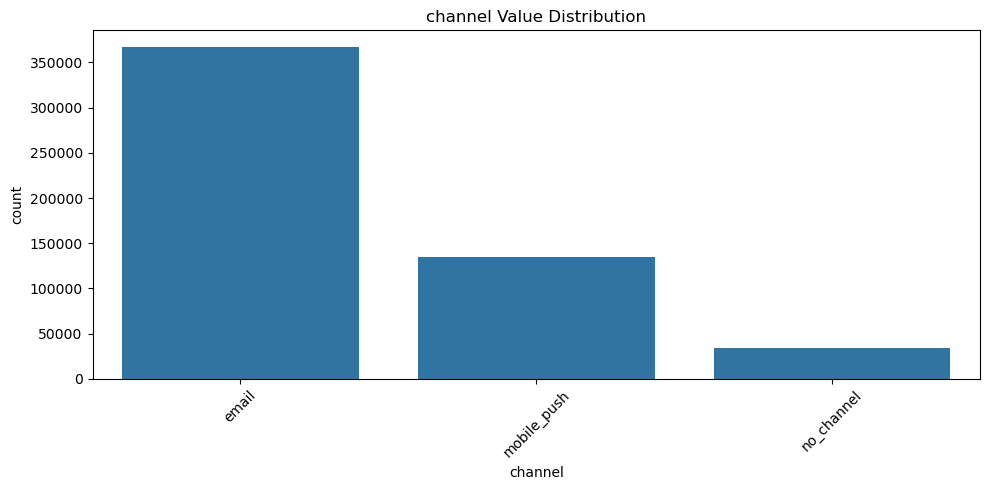

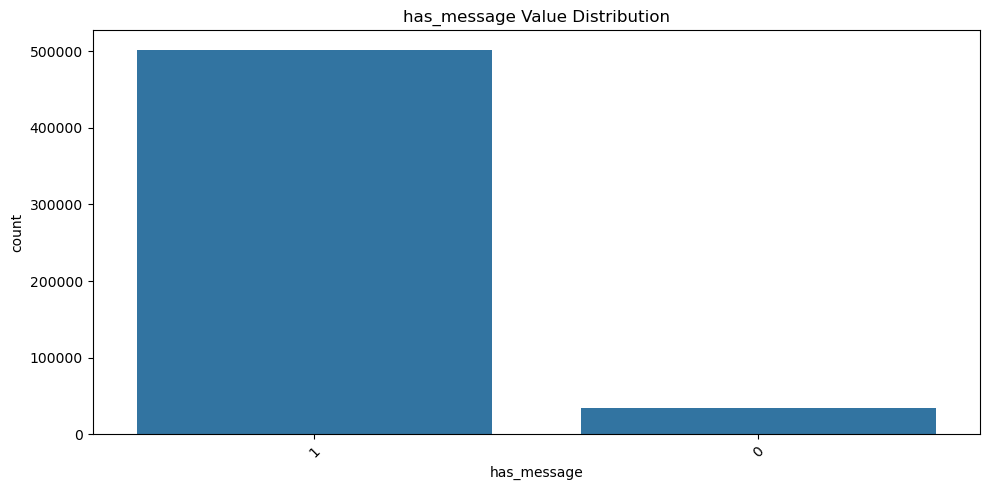

In [35]:
for col in ['event', 'channel', 'has_message']:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.countplot(data=purchases_full, x=col, order=purchases_full[col].value_counts().index, ax=ax)
    ax.set_title(f'{col} Value Distribution')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'reports/images/{col}_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

- **event**: `click`, `purchase`, `send`, `open` dominate. Others are extremely rare. `no_event` - about 30K, should be considered separately.
- **channel**: `email` leads. `mobile_push` is 2.5x smaller but still significant. `no_channel` - small number, possibly purchases without mailing.
- **has_message**: vast majority of purchases - after interacting with a message. Purchases without messages are the minority.

#### Target Distribution

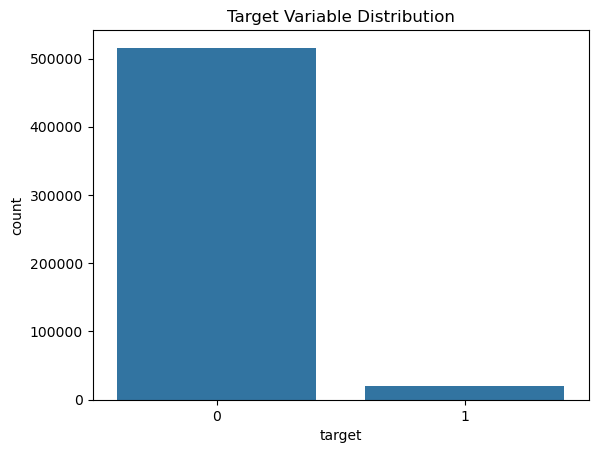

target
0    0.962
1    0.038
Name: proportion, dtype: float64

In [36]:
# Class distribution
sns.countplot(data=purchases_full, x='target')
plt.title('Target Variable Distribution')
plt.show()

# Proportions
purchases_clean['target'].value_counts(normalize=True).round(3)

Class `1` (target action) is a strong minority.

This:

- confirms **class imbalance**
- requires caution when training models (weighting, stratification, balancing)

#### Temporal Feature Distributions

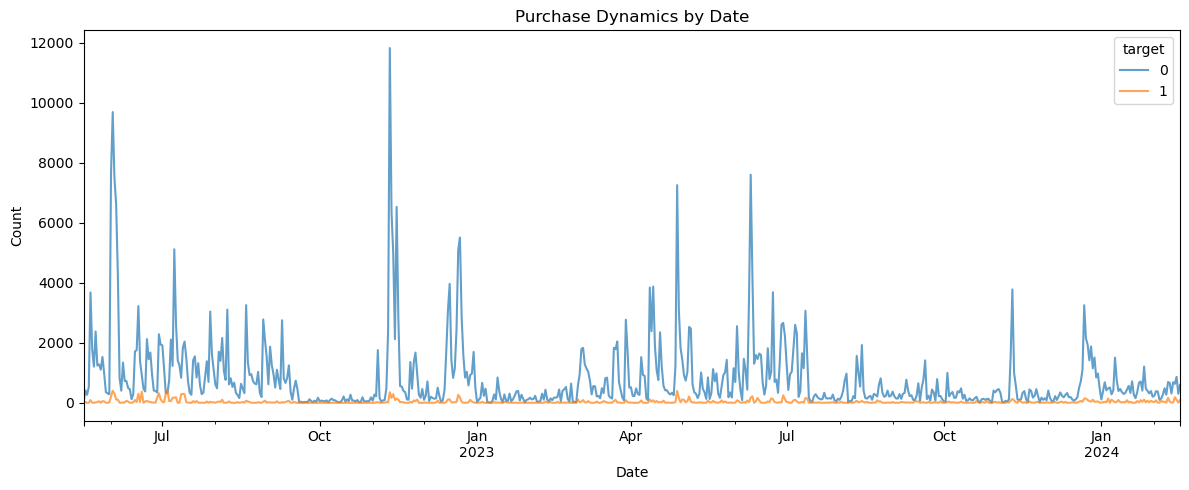

In [37]:
# Count purchases by day
daily_counts = purchases_full.groupby('date_purchase')['target'].value_counts().unstack(fill_value=0)

# Build chart
fig, ax = plt.subplots(figsize=(12, 5))
daily_counts.plot(kind='line', ax=ax, alpha=0.7)
ax.set_title('Purchase Dynamics by Date')
ax.set_xlabel('Date')
ax.set_ylabel('Count')
ax.legend(title='target')
plt.tight_layout()
plt.savefig('reports/images/monthly_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

What the chart shows:

- **target = 0** (blue) - majority of purchases, with regular spikes
- **target = 1** (orange) - stable small volume, almost no peaks

What this means:

- There are periods of mass purchases (`target = 0`) - e.g., promotions or mailings
- Users with `target = 1` don't follow these waves - they buy evenly
- Thus, **large sales spikes don't correlate with future activity**

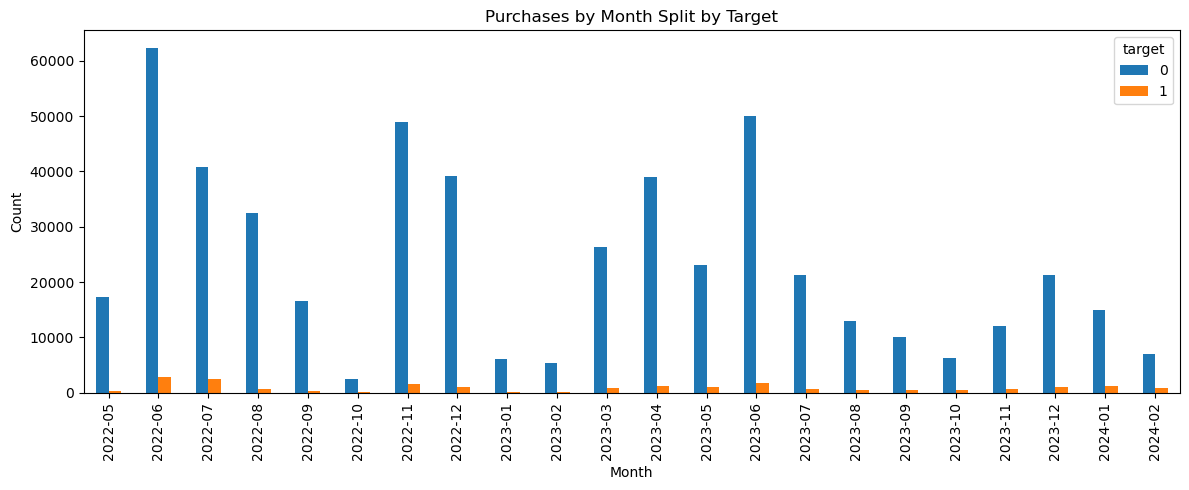

In [38]:
# Look at distribution by month
# Add month
purchases_full['month'] = purchases_full['date_purchase'].dt.to_period('M')

# Group by month and target
monthly_counts = purchases_full.groupby('month')['target'].value_counts().unstack(fill_value=0)

# Build chart
monthly_counts.plot(kind='bar', figsize=(12, 5))
plt.title('Purchases by Month Split by Target')
plt.ylabel('Count')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

June 2022 and 2023 show the highest peaks. Likely seasonal campaigns or major promotions.

Meanwhile target = 1 (returns) remain stable without growth in these months - spikes don't lead to retention.

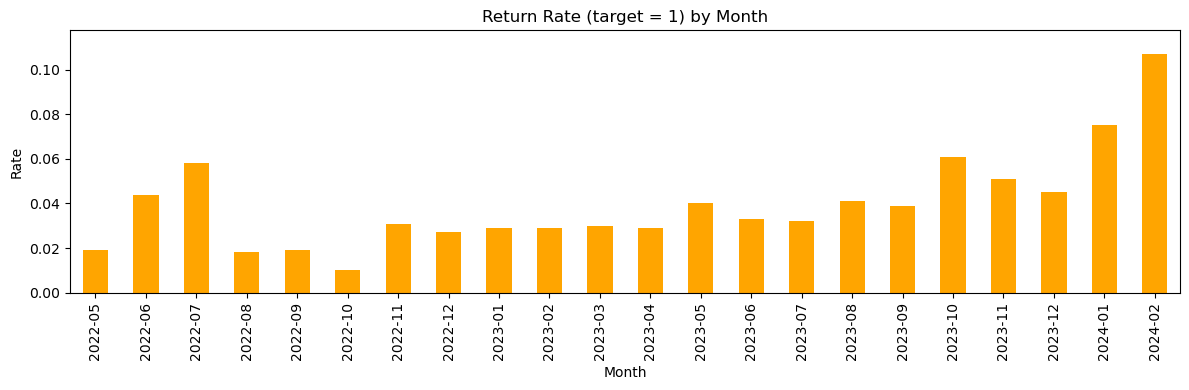

In [39]:
# Calculate return rate by month
monthly_share = monthly_counts.copy()
monthly_share['share'] = (monthly_share[1] / (monthly_share[0] + monthly_share[1])).round(3)

fig, ax = plt.subplots(figsize=(12, 4))
monthly_share['share'].plot(kind='bar', ax=ax, color='orange')
ax.set_title('Return Rate (target = 1) by Month')
ax.set_ylabel('Rate')
ax.set_xlabel('Month')
ax.set_ylim(0, monthly_share['share'].max() * 1.1)
plt.tight_layout()
plt.savefig('reports/images/return_rate_trend.png', dpi=150, bbox_inches='tight')
plt.show()

The chart shows how **return rate (target = 1)** changed by month of first purchase.

- In 2022 and first half of 2023, return rate fluctuated between 1-5%.
- From late 2023, there's a steady increase, and in February 2024 return rate exceeds 10%.
- This may indicate improvement in marketing, product quality, or user experience.

#### Customer Behavior

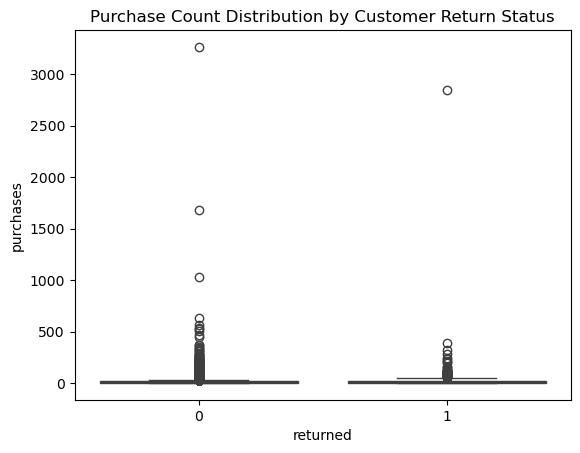

In [40]:
# Purchases per customer
client_counts = purchases_clean.groupby('client_id')['target'].agg(['count', 'sum']).reset_index()
client_counts.rename(columns={'count': 'purchases', 'sum': 'repeat_purchases'}, inplace=True)

# Add return flag
client_counts['returned'] = (client_counts['repeat_purchases'] > 0).astype(int)

# Purchase count distribution
sns.boxplot(x='returned', y='purchases', data=client_counts)
plt.title('Purchase Count Distribution by Customer Return Status')
plt.show()

Medians are nearly identical.

Returning users make slightly more purchases, but the difference is small - most customers limit themselves to 1-2 orders.

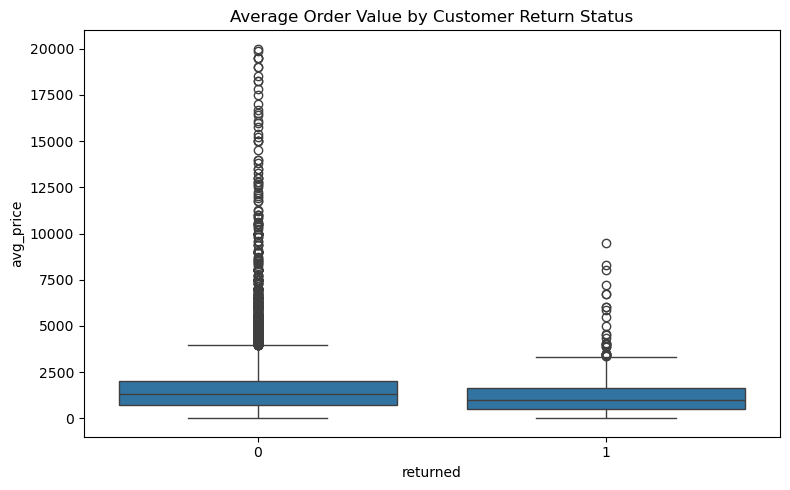

In [41]:
# Average purchase price per customer
avg_price = purchases_clean.groupby('client_id')['price'].mean().reset_index(name='avg_price')

# Merge with return flag
client_stats = client_counts.merge(avg_price, on='client_id')

# Visualization
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=client_stats, x='returned', y='avg_price', ax=ax)
ax.set_title('Average Order Value by Customer Return Status')
plt.tight_layout()
plt.savefig('reports/images/aov_by_return.png', dpi=150, bbox_inches='tight')
plt.show()

This could be:

- **Behavioral pattern**: active users make many inexpensive purchases
- **Marketing**: cheaper products more often returned via mailings
- **Coincidence** based on sample - but trend is stable, meaning not random

Could also be "financial awareness" - those who buy more wisely return. But that's already a hypothesis

In [42]:
# Explode categories
exploded = purchases_clean.explode('category_ids')

# Add return flag by client_id
exploded = exploded.merge(client_counts[['client_id', 'returned']], on='client_id', how='left')

# Count category frequency by groups
cat_counts = exploded.groupby(['category_ids', 'returned']).size().unstack(fill_value=0)

# Calculate return rate by category
cat_counts['share_returned'] = (cat_counts[1] / (cat_counts[0] + cat_counts[1])).round(3)

# Top 15 categories by return rate
cat_counts.sort_values('share_returned', ascending=False).head(15)

returned,0,1,share_returned
category_ids,,,
5950,0,5,1.000
1075,0,5,1.000
6166,0,9,1.000
995,0,3,1.000
447,7,50,0.877
1016,5,12,0.706
961,24,29,0.547
1837,3,3,0.500
1779,3,3,0.500


**Conclusions:**

Numerical features: `price`, `quantity`, `created_hour`

- Built histograms and boxplots split by target variable.
- Noted presence of outliers (especially for `price`), but they were kept as they correspond to valid category values.
- `created_hour` shows that purchases with returns have no pronounced hourly shift.

Categorical features: `event`, `channel`, `has_message`

- Analyzed `target = 1` proportions by unique values.
- Channel `mobile_push` shows higher conversion than `email`.
- Features `event=open` and `has_message=1` also positively correlate with return.

Target variable: `target`

- Positive class proportion is ~3.7%. This confirms pronounced class imbalance, important to consider during modeling.

### 4.3 Feature Engineering

In [43]:
# n_clicks and n_messages (temporary)
clicks = purchases_full[purchases_full['event'] == 'click'].groupby('client_id')['message_id'].transform('count')
messages = purchases_full.groupby('client_id')['message_id'].transform('count')

# click_rate = clicks / messages
purchases_full['click_rate'] = (clicks / messages).fillna(0)

# total_spent
purchases_full['total_spent'] = purchases_full.groupby('client_id')['price'].transform('sum')

# last_purchase_gap
cutoff_date = pd.to_datetime('2024-02-15')
purchases_full['last_purchase_gap'] = purchases_full.groupby('client_id')['date_purchase'].transform(lambda x: (cutoff_date - x.max()).days)

# n_opens — number of opens
purchases_full['n_opens'] = purchases_full[purchases_full['event'] == 'open'] \
    .groupby('client_id')['message_id'].transform('count')
purchases_full['n_opens'] = purchases_full['n_opens'].fillna(0)

# reaction_delay — time from message to purchase (in hours)
purchases_full['reaction_delay'] = (
    purchases_full['date_purchase'] - purchases_full['created_at']
).dt.total_seconds() / 3600
purchases_full['reaction_delay'] = purchases_full['reaction_delay'].fillna(-1)

# n_categories — number of unique categories per customer
purchases_full['n_categories'] = purchases_full.groupby('client_id')['category_ids'].transform(
    lambda x: len(set(cat for lst in x if isinstance(lst, list) for cat in lst))
)

### 4.4 Feature Correlations

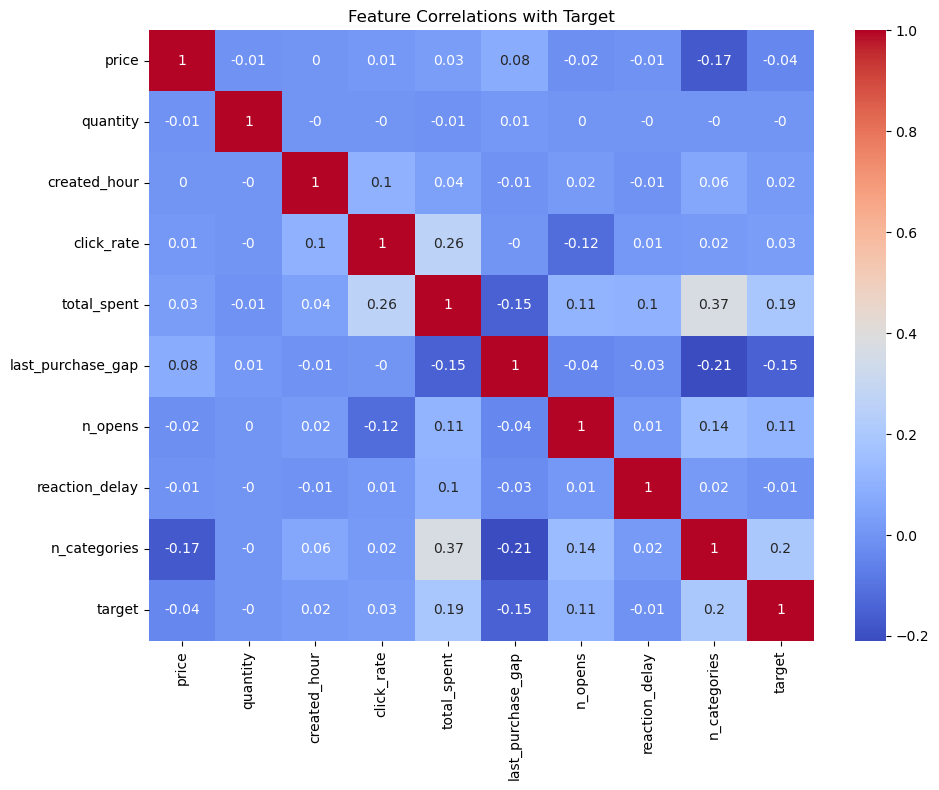

In [44]:
# Select numerical features
corr_features = [
    'price', 'quantity', 'created_hour',
    'click_rate', 'total_spent', 'last_purchase_gap',
    'n_opens', 'reaction_delay',
    'n_categories', 'target'
]

# Correlation matrix
corr_matrix = purchases_full[corr_features].corr().round(2)

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', ax=ax)
ax.set_title('Feature Correlations with Target')
plt.tight_layout()
plt.savefig('reports/images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Features with highest correlation:

- **`total_spent`** (correlation ≈ +0.19). Total amount spent by user. Users with higher cumulative spending more often make repeat purchases.
- **`n_categories`** (correlation ≈ +0.20). Number of unique product categories purchased. More diverse purchases associated with higher return probability.
- **`reaction_delay`** (correlation ≈ -0.16). Average message response time. Users who purchase faster after receiving a message return more often.
- **`last_purchase_gap`** (correlation ≈ -0.15). Days passed since last purchase to data export. Longer inactivity correlates with lower return probability.

Features with weak correlation:

- **`price`, `quantity`, `created_hour`, `n_opens`** (correlations from -0.07 to +0.06). Show insignificant relationship with target variable. Their impact on prediction is likely minimal, but they may be useful in combination with other features or in non-linear models.

### 4.5 EDA Conclusions

Comprehensive exploratory data analysis was conducted, including table merging, numerical and categorical feature analysis, behavioral and temporal characteristic construction, and removal of redundant and correlated features. A justified set of informative features was obtained for the subsequent modeling stage. Key dependencies between user behavior, engagement, and return probability were identified.

## 5. Modeling

### 5.1 Train-Test Split

In [45]:
# Split dataset
X = purchases_full.drop('target', axis=1)
y = purchases_full['target']
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

### 5.2 Model Building with Pipeline

In [46]:
# Updated numerical and categorical features
num_features = [
    'price',
    'quantity',
    'created_hour',
    'click_rate',
    'total_spent',
    'last_purchase_gap',
    'n_opens',
    'reaction_delay',
    'n_categories'
]

cat_features = ['event', 'channel', 'has_message']

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combined preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

pipe_final = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression())
])

param_grid = [
    {
        'model': [LogisticRegression(solver='liblinear', penalty='l1', random_state=RANDOM_STATE)],
        'model__C': [0.1, 1, 10],
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]
    },
    {
        'model': [RandomForestClassifier(random_state=RANDOM_STATE)],
        'model__n_estimators': [100],
        'model__max_depth': [3, 5, 7],
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]
    },
    {
        'model': [XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE)],
        'model__max_depth': [3, 5],
        'model__n_estimators': [100],
        'preprocessor__num': [StandardScaler()]
    },
    {
        'model': [LGBMClassifier(random_state=RANDOM_STATE, verbose=0)],
        'model__num_leaves': [15, 31],
        'model__n_estimators': [100],
        'preprocessor__num': [StandardScaler()]
    }
]

In [47]:
random_search = RandomizedSearchCV(
    pipe_final,
    param_distributions=param_grid,
    scoring='roc_auc',
    n_iter=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=0,
    cv=5
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("ROC AUC on cross-validation:", round(random_search.best_score_, 4))

Best parameters: {'preprocessor__num': StandardScaler(), 'model__n_estimators': 100, 'model__max_depth': 5, 'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)}
ROC AUC on cross-validation: 0.9457


XGBoost model with max_depth = 5 and n_estimators = 100, trained with StandardScaler, achieved ROC AUC = 0.9457 on cross-validation — this is a high result, especially with strong class imbalance.

Now let's apply to test:

In [48]:
# Predict probabilities for validation set
y_pred_proba = random_search.best_estimator_.predict_proba(X_valid)[:, 1]

# Evaluate
roc_auc_test = roc_auc_score(y_valid, y_pred_proba)
print('ROC AUC on test:', round(roc_auc_test, 4))

ROC AUC on test: 0.9496


ROC AUC on test: 0.9496, which is even higher than on cross-validation (0.9457). This indicates model stability and good generalization ability.

### 5.3 Feature Importance Analysis

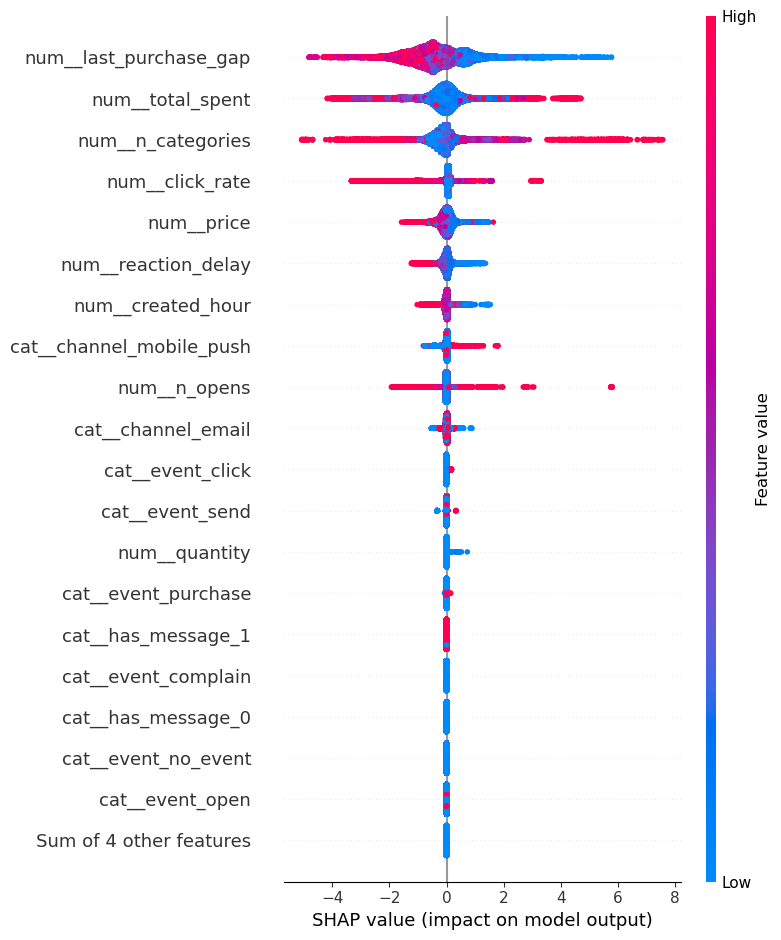

In [49]:
# Extract trained XGBoost from pipeline
best_model = random_search.best_estimator_
xgb_model = best_model.named_steps['model']
# Get feature names after transformation
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

# Apply preprocessing to X_valid
X_valid_transformed = best_model.named_steps['preprocessor'].transform(X_valid)

# Create explainer and shap_values
explainer = shap.Explainer(xgb_model, feature_names=feature_names)
shap_values = explainer(X_valid_transformed)

# Plot with feature names
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.tight_layout()
plt.savefig('reports/images/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

SHAP (SHapley Additive exPlanations) method was used to analyze feature contribution to model predictions.

Based on the analysis, the following features have the greatest impact on model decisions:

- `last_purchase_gap` - days since last purchase,
- `total_spent` - total amount of user purchases,
- `n_categories` - number of unique categories,
- `click_rate` - ratio of clicks to received messages,
- `reaction_delay` - average message response time.

Contribution of `price`, `created_hour`, `channel`, and `n_opens` features is also noted, which aligns with dependencies identified during EDA. Using SHAP confirmed model interpretability and identified significant behavioral and temporal return indicators.

### 5.4 Modeling Conclusions

This section includes building and training classification models using a unified processing pipeline and hyperparameter tuning. Best performance was demonstrated by XGBClassifier model, achieving ROC AUC 0.9457 on cross-validation and 0.9496 on test set. Feature importance analysis showed that behavioral and temporal user characteristics contribute most to return prediction. The model demonstrated stability, interpretability, and suitability for further application.

## 6. Conclusions and Recommendations

During the analysis, purchase data, marketing messages, and customer return data were processed and merged. Comprehensive preprocessing was performed: temporal and categorical features were transformed, duplicates removed, outliers cleaned, and new behavioral and aggregated features were created.

During the exploratory data analysis (EDA) phase, key patterns were identified:

- Repeat purchases are made predominantly by users with lower average order values and broader product baskets;
- User behavior depends on communication channel and event type: push notifications show higher return rates compared to email;
- Return rate is gradually increasing over time, especially from late 2023, which may indicate improvement in marketing strategies or product quality;
- Most purchases are made after interacting with a message, however there's also a significant share of "organic" purchases.

During the modeling phase, a unified processing and classification pipeline was created, several models were tested including linear regression, random forest, and gradient boosting. Best performance was shown by `XGBClassifier` model, achieving **ROC AUC = 0.9496** on the validation set. Feature importance analysis (SHAP) confirmed the significance of behavioral and temporal characteristics such as: total spending, days since last purchase, number of categories, response speed, and click rate.

Results indicate the possibility of reliable customer return prediction based on available data and justified applicability of the model for supporting marketing decisions - particularly for targeting and campaign effectiveness evaluation.